In [1]:
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import DQN

# Set up environment
env = gym.make("CartPole-v1", render_mode="rgb_array")

# Path to models
dqn_model_dir = "./dqn_models"  # Update this path as needed

# Filter DQN model files
model_files = [f for f in os.listdir(dqn_model_dir) if f.startswith("dqn_cartpole") and f.endswith(".zip")]

2025-05-04 00:09:11.542431: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-04 00:09:11.556539: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-04 00:09:11.560904: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-04 00:09:11.571601: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


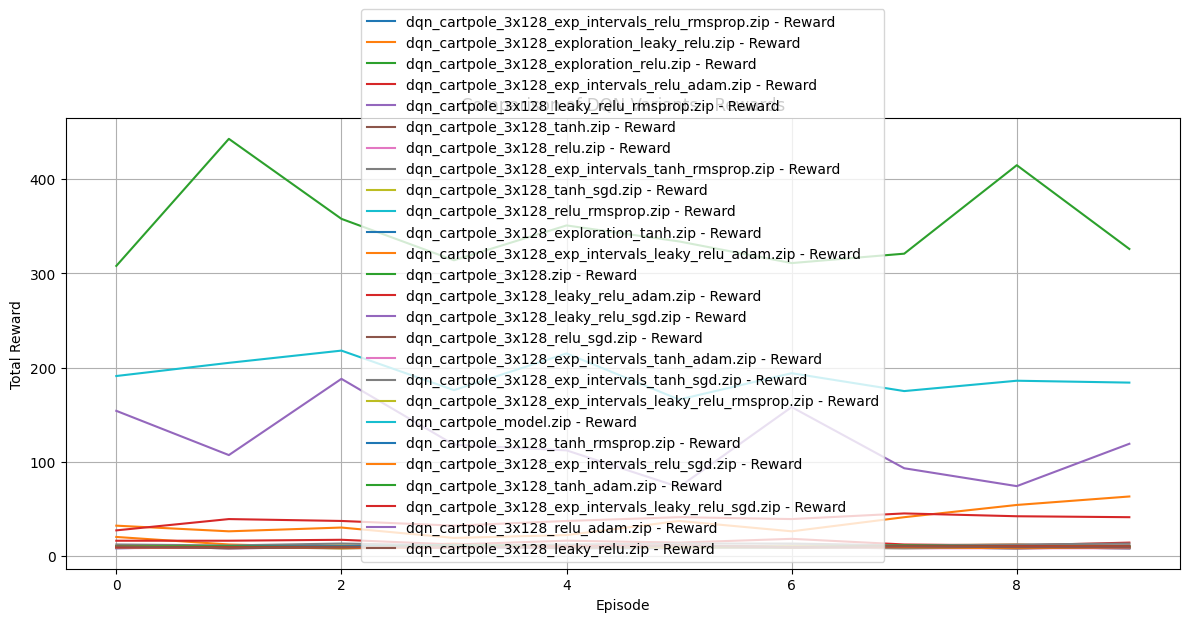

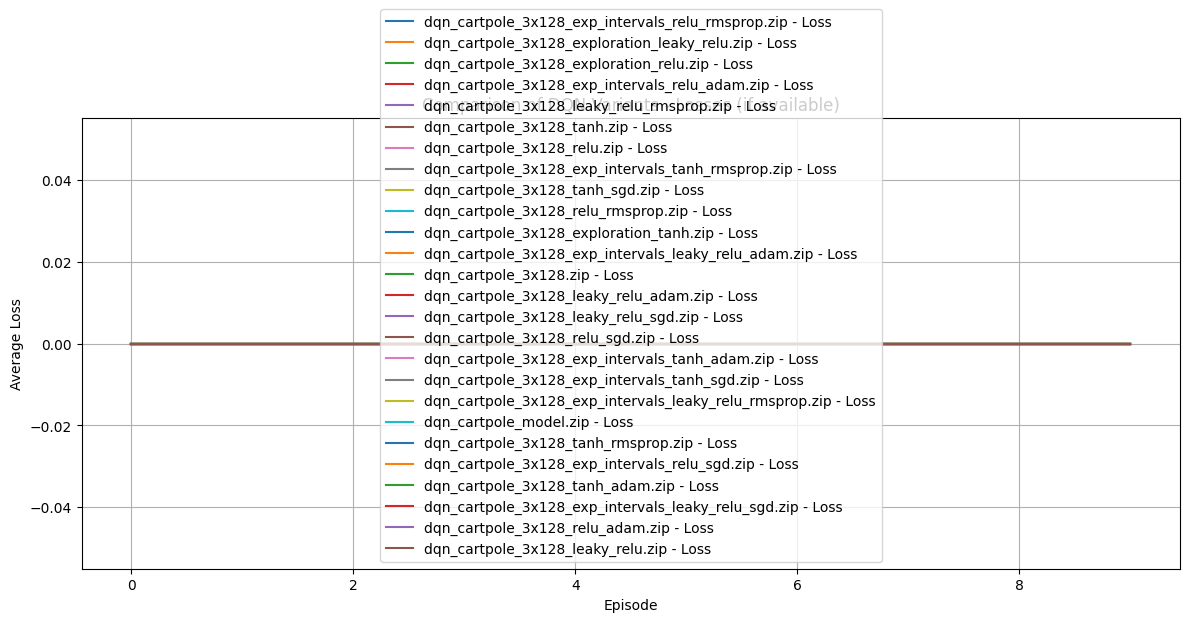

In [3]:
results = {}
losses = {}

# Evaluation parameters
NUM_EPISODES = 10

# Evaluate each model
for model_file in model_files:
    model_path = os.path.join(dqn_model_dir, model_file)
    model = DQN.load(model_path)

    episode_rewards = []
    episode_losses = []

    for _ in range(NUM_EPISODES):
        obs, _ = env.reset()
        done = False
        total_reward = 0
        total_loss = 0
        steps = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
            
            # Try to get loss (if available)
            if hasattr(model, "logger") and hasattr(model.logger, "name_to_value"):
                loss_val = model.logger.name_to_value.get("train/loss", np.nan)
                total_loss += loss_val if loss_val is not None else 0

            steps += 1

        episode_rewards.append(total_reward)
        if steps > 0:
            episode_losses.append(total_loss / steps)
        else:
            episode_losses.append(np.nan)

    results[model_file] = episode_rewards
    losses[model_file] = episode_losses

# Close environment
env.close()

# Plot comparison - Rewards
plt.figure(figsize=(12, 6))
for model_file, rewards in results.items():
    plt.plot(rewards, label=f"{model_file} - Reward")

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Comparison of DQN Variants - Rewards")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot comparison - Losses
plt.figure(figsize=(12, 6))
for model_file, loss_vals in losses.items():
    plt.plot(loss_vals, label=f"{model_file} - Loss")

plt.xlabel("Episode")
plt.ylabel("Average Loss")
plt.title("Comparison of DQN Variants - Losses (if available)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

